<a href="https://colab.research.google.com/github/PatandyaW/Skripsikkk/blob/main/Skripsik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
net_df = pd.read_csv('/content/drive/My Drive/dataskripshit/netflix_titles.csv')
net_df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5331,s5332,Movie,Naked,Michael Tiddes,"Marlon Wayans, Regina Hall, Dennis Haysbert, L...",United States,"August 11, 2017",2017,TV-14,97 min,"Comedies, Romantic Movies",Rob's madly in love and about to be married. U...
2472,s2473,TV Show,Betaal,NaN,"Viineet Kumar, Aahana Kumra, Suchitra Pillai, ...",India,"May 24, 2020",2020,TV-MA,1 Season,"International TV Shows, TV Action & Adventure,...",Hired to displace tribal villagers to make way...
5953,s5954,Movie,Joseph: King of Dreams,"Rob LaDuca, Robert C. Ramirez","Ben Affleck, Mark Hamill, Richard Herd, Mauree...","United States, France, United Kingdom","September 27, 2011",2000,TV-PG,75 min,"Children & Family Movies, Dramas, Faith & Spir...",With his gift of dream interpretation and his ...
1501,s1502,Movie,After We Collided,Roger Kumble,"Josephine Langford, Hero Fiennes Tiffin, Dylan...",United States,"December 22, 2020",2020,R,105 min,"Dramas, Romantic Movies","Tessa fell hard and fast for Hardin, but after..."
6143,s6144,Movie,American History X,Tony Kaye,"Edward Norton, Edward Furlong, Beverly D'Angel...",United States,"November 1, 2019",1998,R,119 min,Dramas,A neo-Nazi gets sent to prison for murder and ...


In [4]:
net_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
net_df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [6]:
net_df[net_df.director.isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada","May 1, 2018",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


In [7]:
print("Jumlah duplikasi: ", net_df.duplicated().sum())

Jumlah duplikasi:  0


In [8]:
for i in net_df.columns:
    null_rate = net_df[i].isna().sum() / len(net_df) * 100
    if null_rate > 0 :
        print("{} null rate: {}%".format(i,round(null_rate,2)))

director null rate: 29.91%
cast null rate: 9.37%
country null rate: 9.44%
date_added null rate: 0.11%
rating null rate: 0.05%
duration null rate: 0.03%


In [9]:
# net_df.describe(include="all")

In [10]:
net_df['country'] = net_df['country'].fillna(net_df['country'].mode()[0])
net_df['cast'].replace(np.nan, 'No Data',inplace  = True)
net_df['director'].replace(np.nan, 'No Data',inplace  = True)


net_df.dropna(inplace=True)
net_df.drop_duplicates(inplace= True)

<ipython-input-10-558a2bed9fc2>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  net_df['cast'].replace(np.nan, 'No Data',inplace  = True)
<ipython-input-10-558a2bed9fc2>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [11]:
net_df["date_added"] = net_df["date_added"].str.strip()

net_df["date_added"] = pd.to_datetime(net_df['date_added'])

net_df['month_added']=net_df['date_added'].dt.month
net_df['month_name_added']=net_df['date_added'].dt.month_name()
net_df['year_added'] = net_df['date_added'].dt.year
net_df['day_name_added'] = net_df['date_added'].dt.day_name()


In [12]:
time = net_df["year_added"] - net_df["release_year"]

# simpan data di kolom baru 'time' (ini tahun)
net_df["time"] = time
net_df.head(15)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added,day_name_added,time
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,September,2021,Saturday,1
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,September,2021,Friday,0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,September,2021,Friday,0
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,September,2021,Friday,0
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,September,2021,Friday,0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,9,September,2021,Friday,0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,9,September,2021,Friday,0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",9,September,2021,Friday,28
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,9,September,2021,Friday,0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,9,September,2021,Friday,0


In [13]:
net_df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added,day_name_added,time
count,8790,8790,8790,8790,8790,8790,8790,8790.000000,8790,8790,8790,8790,8790.000000,8790,8790.000000,8790,8790.000000
unique,8790,2,8790,4527,7679,748,NaN,NaN,14,220,513,8758,NaN,12,NaN,7,NaN
top,s8807,Movie,Zubaan,No Data,No Data,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",NaN,July,NaN,Friday,NaN
freq,1,6126,1,2621,825,3638,NaN,NaN,3205,1791,362,4,NaN,827,NaN,2497,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-17 21:44:01.638225408,2014.183163,NaN,NaN,NaN,NaN,6.655859,NaN,2018.873606,NaN,4.690444
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN,1.000000,NaN,2008.000000,NaN,-3.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-06 00:00:00,2013.000000,NaN,NaN,NaN,NaN,4.000000,NaN,2018.000000,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-03 00:00:00,2017.000000,NaN,NaN,NaN,NaN,7.000000,NaN,2019.000000,NaN,1.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-19 18:00:00,2019.000000,NaN,NaN,NaN,NaN,10.000000,NaN,2020.000000,NaN,5.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,NaN,12.000000,NaN,2021.000000,NaN,93.000000


Berdasarkan hasil tersebut, dapat diketahui bahwa rata-rata waktu rilis konten film/acara tv terlampau selama 4 tahun dengan nilai tahun maksimum sebesar 93 tahun.

In [14]:
# Calculate time difference in years for movies
net_df.loc[net_df['type'] == 'Movie', 'time2'] = net_df['year_added'] - net_df['release_year']

# Calculate time difference in years for TV shows
net_df.loc[net_df['type'] == 'TV Show', 'time3'] = net_df['year_added'] - net_df['release_year']

# Display the first 15 rows to verify
net_df.describe(include="all")


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added,day_name_added,time,time2,time3
count,8790,8790,8790,8790,8790,8790,8790,8790.000000,8790,8790,8790,8790,8790.000000,8790,8790.000000,8790,8790.000000,6126.000000,2664.000000
unique,8790,2,8790,4527,7679,748,NaN,NaN,14,220,513,8758,NaN,12,NaN,7,NaN,NaN,NaN
top,s8807,Movie,Zubaan,No Data,No Data,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",NaN,July,NaN,Friday,NaN,NaN,NaN
freq,1,6126,1,2621,825,3638,NaN,NaN,3205,1791,362,4,NaN,827,NaN,2497,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-17 21:44:01.638225408,2014.183163,NaN,NaN,NaN,NaN,6.655859,NaN,2018.873606,NaN,4.690444,5.730983,2.297673
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN,1.000000,NaN,2008.000000,NaN,-3.000000,-1.000000,-3.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-06 00:00:00,2013.000000,NaN,NaN,NaN,NaN,4.000000,NaN,2018.000000,NaN,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-03 00:00:00,2017.000000,NaN,NaN,NaN,NaN,7.000000,NaN,2019.000000,NaN,1.000000,2.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-19 18:00:00,2019.000000,NaN,NaN,NaN,NaN,10.000000,NaN,2020.000000,NaN,5.000000,7.000000,2.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,NaN,12.000000,NaN,2021.000000,NaN,93.000000,75.000000,93.000000


**Film**

Berdasarkan hasil tersebut, dapat diketahui bahwa rata-rata waktu rilis konten film terlampau selama 5.730983 tahun dengan nilai tahun maksimum sebesar 75 tahun.

**Acara TV**

Sedangkan kita dapat diketahui bahwa rata-rata waktu rilis konten acara tv terlampau selama 2.297673 tahun dengan nilai tahun maksimum sebesar 93 tahun.

In [15]:
net_df["listed_in"].unique()

array(['Documentaries', 'International TV Shows, TV Dramas, TV Mysteries',
       'Crime TV Shows, International TV Shows, TV Action & Adventure',
       'Docuseries, Reality TV',
       'International TV Shows, Romantic TV Shows, TV Comedies',
       'TV Dramas, TV Horror, TV Mysteries', 'Children & Family Movies',
       'Dramas, Independent Movies, International Movies',
       'British TV Shows, Reality TV', 'Comedies, Dramas',
       'Crime TV Shows, Docuseries, International TV Shows',
       'Dramas, International Movies',
       'Children & Family Movies, Comedies',
       'British TV Shows, Crime TV Shows, Docuseries',
       'TV Comedies, TV Dramas', 'Documentaries, International Movies',
       'Crime TV Shows, Spanish-Language TV Shows, TV Dramas',
       'Thrillers',
       'International TV Shows, Spanish-Language TV Shows, TV Action & Adventure',
       'International TV Shows, TV Action & Adventure, TV Dramas',
       'Comedies, International Movies',
       'Comedies, 

In [16]:
from collections import Counter

all_genres = [genre.strip() for sublist in net_df["listed_in"].str.split(',') for genre in sublist]
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)

print(genre_df)


                           Genre  Count
14          International Movies   2752
12                        Dramas   2426
16                      Comedies   1674
1         International TV Shows   1349
0                  Documentaries    869
25            Action & Adventure    859
2                      TV Dramas    762
13            Independent Movies    756
11      Children & Family Movies    641
19               Romantic Movies    616
18                     Thrillers    577
9                    TV Comedies    573
4                 Crime TV Shows    469
24                      Kids' TV    448
6                     Docuseries    394
20              Music & Musicals    375
8              Romantic TV Shows    370
21                 Horror Movies    357
38               Stand-Up Comedy    343
7                     Reality TV    255
15              British TV Shows    252
22              Sci-Fi & Fantasy    243
29                 Sports Movies    219
30                  Anime Series    174


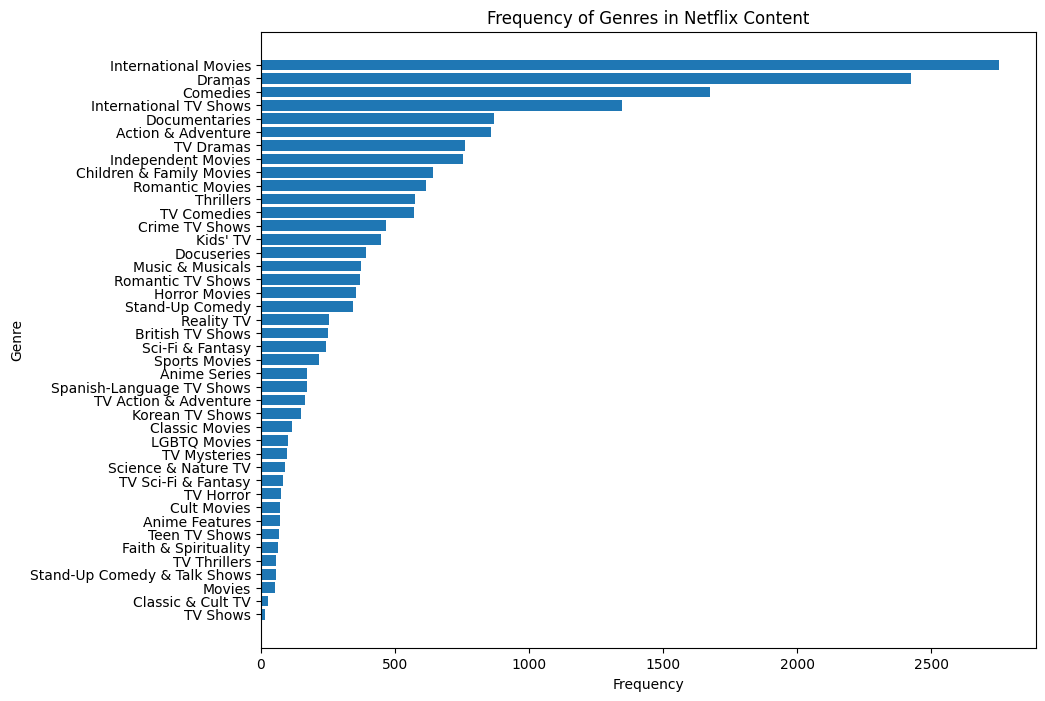

In [17]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 8))
plt.barh(genre_df['Genre'], genre_df['Count'])
plt.xlabel('Frequency')
plt.ylabel('Genre')
plt.title('Frequency of Genres in Netflix Content')
plt.gca().invert_yaxis()
plt.show()

In [18]:
net_df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,month_name_added,year_added,day_name_added,time,time2,time3
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,September,2021,Saturday,1,1.0,NaN
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,September,2021,Friday,0,NaN,0.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,September,2021,Friday,0,NaN,0.0
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,September,2021,Friday,0,NaN,0.0
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,September,2021,Friday,0,NaN,0.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,9,September,2021,Friday,0,NaN,0.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,9,September,2021,Friday,0,0.0,NaN
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",9,September,2021,Friday,28,28.0,NaN
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,9,September,2021,Friday,0,NaN,0.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,9,September,2021,Friday,0,0.0,NaN


In [19]:
net_df.month_name_added.value_counts()

,count
month_name_added,
July,827
December,812
September,769
April,763
October,760
August,754
March,741
January,737
June,728


In [20]:
net_df["weather_group"] = net_df["month_added"].apply(
    lambda x: "winter" if x <= 2 or x == 12
    else "spring" if 3 <= x <= 5
    else "summer" if 6 <= x <= 8
    else "fall"
)

season_counts = net_df.groupby(by="weather_group")["show_id"].nunique().sort_values(ascending=False)

season_counts

,show_id
weather_group,
summer,2309
fall,2234
spring,2136
winter,2111


**Fall** (23 September – 20 Desember), **Winter** (21 Desember – 20 Maret), **Spring** (21 Maret – 20 Juni) dan **Summer** (21 Juni – 22 September).

Jika dilihat dari pembagian musim berdasarkan tanggal diatas,Bisa diambil kesimpulan bahwa, banyak distributor film merilis film/acara tv pada musim panas

In [21]:
net_df.rename(columns={
    'rating': 'age_ratings'
}, inplace=True)

net_df.head()


,show_id,type,title,director,cast,country,date_added,release_year,age_ratings,duration,listed_in,description,month_added,month_name_added,year_added,day_name_added,time,time2,time3,weather_group
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,September,2021,Saturday,1,1.0,NaN,fall
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,September,2021,Friday,0,NaN,0.0,fall
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,September,2021,Friday,0,NaN,0.0,fall
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,September,2021,Friday,0,NaN,0.0,fall
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,September,2021,Friday,0,NaN,0.0,fall


In [22]:
unique_movies = net_df[net_df['type'] == 'Movie']['title'].nunique()
unique_tv_shows = net_df[net_df['type'] == 'TV Show']['title'].nunique()


print("MOVIES =", unique_movies)
print("TV SHOWS =", unique_tv_shows)

MOVIES = 6126
TV SHOWS = 2664


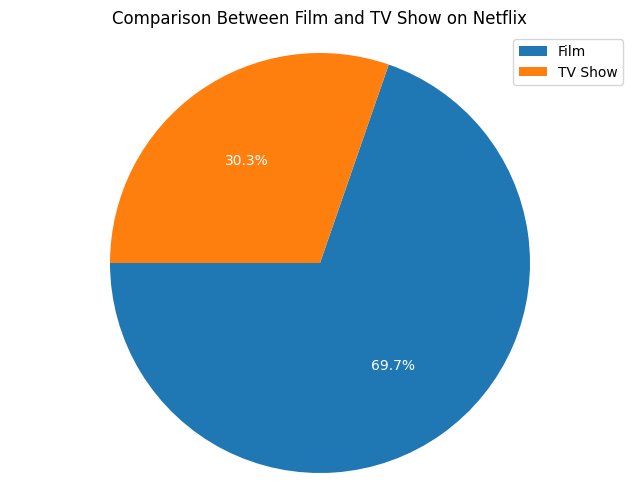

In [23]:
import matplotlib.pyplot as plt

labels = 'Film', 'TV Show'
sizes = [unique_movies, unique_tv_shows]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=180, textprops={'color':"white"})
plt.axis('equal')


plt.title('Comparison Between Film and TV Show on Netflix')
plt.legend()


plt.show()

In [24]:
# Group by 'year_added' and 'type', then count the occurrences
type_per_year = net_df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

# Display the result
print(type_per_year)

type        Movie  TV Show
year_added                
2008            1        1
2009            2        0
2010            1        0
2011           13        0
2012            3        0
2013            6        5
2014           19        5
2015           56       26
2016          251      175
2017          836      349
2018         1237      411
2019         1424      592
2020         1284      595
2021          993      505


<Figure size 1200x800 with 0 Axes>

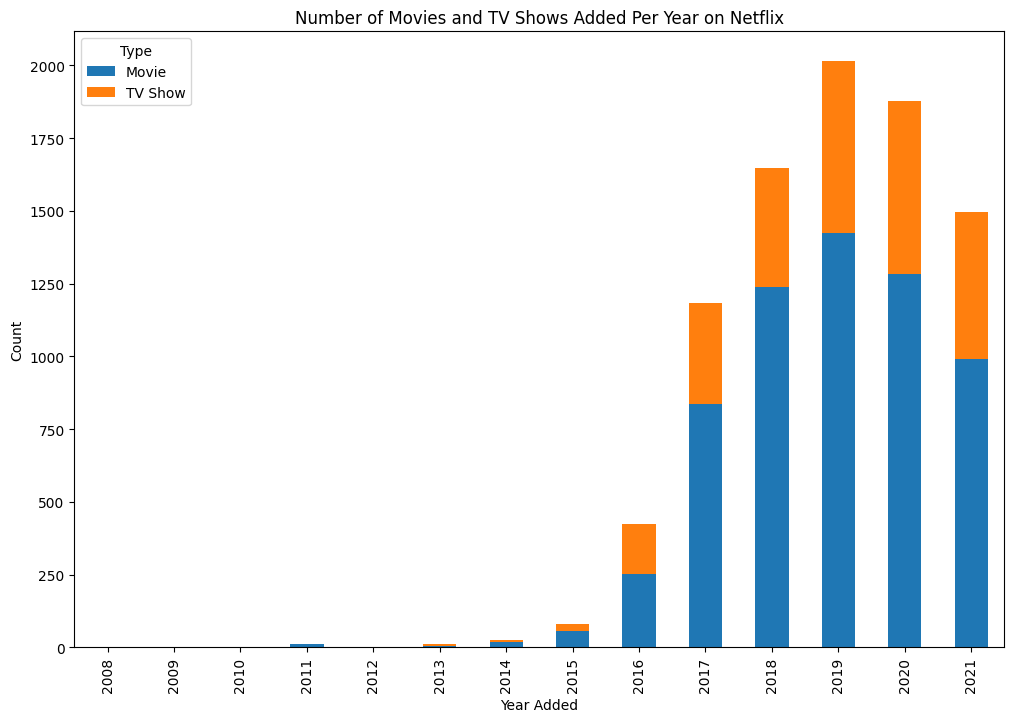

In [25]:
type_per_year = net_df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
type_per_year.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], figsize=(12, 8))

plt.xlabel('Year Added')
plt.ylabel('Count')
plt.title('Number of Movies and TV Shows Added Per Year on Netflix')
plt.legend(title="Type")

plt.show()

**Perbandingan Netflix dalam merilis suatu Film/Acara TV**

Dari diatas dapat diambil kesimpulan bahwa netflix merilis lebih banyak film dibandingkan acara tv, Netflix juga telah merilis besar-besaran pada tahun 2019 jika dibandingkan pada tahun sebelum dan sesudahnya.


**Dari berbagai film/acara tv yang dirilis pihak Netflix sering merilis pada bulan apa?**


In [26]:
tv_shows_data = net_df[net_df['type'] == 'TV Show'].copy()
movies_data = net_df[net_df['type'] == 'Movie'].copy()

movies_data['month'] = movies_data['date_added'].dt.month
tv_shows_data['month'] = tv_shows_data['date_added'].dt.month

movies_monthly_count = movies_data.groupby('month')['title'].nunique().reset_index()

tv_shows_monthly_count = tv_shows_data.groupby('month')['title'].nunique().reset_index()

best_month_movies = movies_monthly_count.sort_values('title', ascending=False).iloc[0]
best_month_tv_shows = tv_shows_monthly_count.sort_values('title', ascending=False).iloc[0]

best_month_movies, best_month_tv_shows

#bulan yang sering upload

(month      7
 title    565
 Name: 6, dtype: int64,
 month     12
 title    265
 Name: 11, dtype: int64)

Dari output diatas didapatkan bahwa film merilis paling banyak pada bulan july yang memiliki nilai sebanyak 565(Summer)

dan acara tv pada bulan desember yang memiliki nilai sebanyak 265 (Winter)

In [27]:
net_df['month'] = net_df['date_added'].dt.month
shows_monthly_rate = net_df.groupby(['age_ratings', 'month'])['title'].nunique().reset_index()

best_months_by_rating = shows_monthly_rate.sort_values(['age_ratings', 'title'], ascending=[True, False]).drop_duplicates('age_ratings')
print(best_months_by_rating)

    age_ratings  month  title
3             G      4      8
11        NC-17      1      1
25           NR     12     12
26           PG      1     38
38        PG-13      1     72
50            R      1    108
73        TV-14     12    222
80         TV-G      7     33
91        TV-MA      6    314
109       TV-PG     12     97
119        TV-Y     10     41
122       TV-Y7      1     48
134    TV-Y7-FV      2      2
138          UR      6      1


Dari output diatas didapatkan bahwa age ratings safe for watch untuk anak-anak ataupun di tonton bersama keluarga memiliki pola lebih banyak rilis pada musim liburan

In [28]:
def unnest_dataframe(df, column):
    return (
        df.drop(column, axis=1)
        .join(
            df[column].str.split(',', expand=True)
            .stack()
            .reset_index(level=1, drop=True)
            .rename(column)
        )
    )

unnested_country = unnest_dataframe(net_df, 'country')

unnested_country.head(15)

,show_id,type,title,director,cast,date_added,release_year,age_ratings,duration,listed_in,...,month_added,month_name_added,year_added,day_name_added,time,time2,time3,weather_group,month,country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,2021-09-25,2020,PG-13,90 min,Documentaries,...,9,September,2021,Saturday,1,1.0,NaN,fall,9,United States
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",...,9,September,2021,Friday,0,NaN,0.0,fall,9,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",...,9,September,2021,Friday,0,NaN,0.0,fall,9,United States
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",...,9,September,2021,Friday,0,NaN,0.0,fall,9,United States
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",...,9,September,2021,Friday,0,NaN,0.0,fall,9,India
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",...,9,September,2021,Friday,0,NaN,0.0,fall,9,United States
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",2021-09-24,2021,PG,91 min,Children & Family Movies,...,9,September,2021,Friday,0,0.0,NaN,fall,9,United States
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",...,9,September,2021,Friday,28,28.0,NaN,fall,9,United States
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",...,9,September,2021,Friday,28,28.0,NaN,fall,9,Ghana
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",...,9,September,2021,Friday,28,28.0,NaN,fall,9,Burkina Faso


In [29]:
all_country = [country.strip() for sublist in net_df["country"].str.split(',') for country in sublist]
country_count = Counter(all_country)
country_df = pd.DataFrame(country_count.items(), columns=['country', 'Count']).sort_values(by='Count', ascending=False)

print(country_df)


            country  Count
0     United States   4510
2             India   1046
5    United Kingdom    805
15           Canada    445
12           France    393
..              ...    ...
118           Sudan      1
119          Panama      1
120          Uganda      1
121    East Germany      1
122      Montenegro      1

[123 rows x 2 columns]


In [30]:

# unnested_country['country'] = unnested_country['country'].str.strip().str.title()


# country_data = unnested_country.groupby('country').size().reset_index(name='count')


# country_data = country_data.sort_values(by='count', ascending=False)

# country_data.head(15)

In [31]:
# countrydfo = net_df['country'].value_counts()
# countrydfo

In [32]:
unnested_age_ratings = unnest_dataframe(net_df, 'age_ratings')

unnested_age_ratings.head(15)

,show_id,type,title,director,cast,country,date_added,release_year,duration,listed_in,...,month_added,month_name_added,year_added,day_name_added,time,time2,time3,weather_group,month,age_ratings
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,2021-09-25,2020,90 min,Documentaries,...,9,September,2021,Saturday,1,1.0,NaN,fall,9,PG-13
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",...,9,September,2021,Friday,0,NaN,0.0,fall,9,TV-MA
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,1 Season,"Crime TV Shows, International TV Shows, TV Act...",...,9,September,2021,Friday,0,NaN,0.0,fall,9,TV-MA
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,United States,2021-09-24,2021,1 Season,"Docuseries, Reality TV",...,9,September,2021,Friday,0,NaN,0.0,fall,9,TV-MA
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",...,9,September,2021,Friday,0,NaN,0.0,fall,9,TV-MA
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,1 Season,"TV Dramas, TV Horror, TV Mysteries",...,9,September,2021,Friday,0,NaN,0.0,fall,9,TV-MA
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,91 min,Children & Family Movies,...,9,September,2021,Friday,0,0.0,NaN,fall,9,PG
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,125 min,"Dramas, Independent Movies, International Movies",...,9,September,2021,Friday,28,28.0,NaN,fall,9,TV-MA
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,9 Seasons,"British TV Shows, Reality TV",...,9,September,2021,Friday,0,NaN,0.0,fall,9,TV-14
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,104 min,"Comedies, Dramas",...,9,September,2021,Friday,0,0.0,NaN,fall,9,PG-13


In [33]:
unique_titles_per_age_ratings = unnested_age_ratings.groupby('age_ratings')['show_id'].nunique()

# Sorting the result in descending order
unique_titles_per_age_ratings_sorted = unique_titles_per_age_ratings.sort_values(ascending=False)

# Displaying the result
unique_titles_per_age_ratings_sorted

,show_id
age_ratings,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


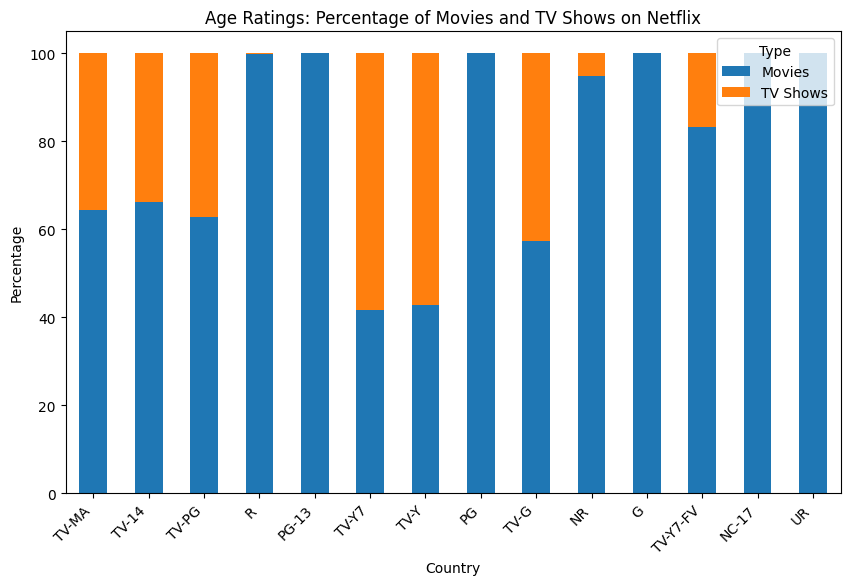

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns


filtered_age_ratings_data = unnested_age_ratings[unnested_age_ratings['age_ratings'] != 'Unknown age_ratings']

age_ratings_type_counts = filtered_age_ratings_data.groupby(['age_ratings', 'type']).size().unstack().fillna(0)

top_age_ratings = age_ratings_type_counts.sum(axis=1).sort_values(ascending=False)


top_age_ratings_data = age_ratings_type_counts.loc[top_age_ratings.index]


top_age_ratings_data_percentage = top_age_ratings_data.div(top_age_ratings_data.sum(axis=1), axis=0) * 100


plt.figure(figsize=(10, 6))
top_age_ratings_data_percentage.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Age Ratings: Percentage of Movies and TV Shows on Netflix')
plt.xlabel('Country')
plt.ylabel('Percentage')
plt.legend(title='Type', labels=['Movies', 'TV Shows'])
plt.xticks(rotation=45, ha='right')
plt.show()

In [35]:
# from sklearn.preprocessing import LabelEncoder

# # Copy of the dataframe to avoid overwriting
# encoded_df = net_df.copy()

# # Encode 'type' and 'rating' using LabelEncoder
# label_encoder = LabelEncoder()
# encoded_df['type'] = label_encoder.fit_transform(encoded_df['type'])
# encoded_df['age_ratings'] = label_encoder.fit_transform(encoded_df['age_ratings'])

# # Select numeric columns and encoded categorical columns
# selected_columns = encoded_df[['release_year', 'type', 'age_ratings']]

# # Calculate correlation matrix
# correlation = selected_columns.corr()

# # Plot heatmap
# plt.figure(figsize=(10, 8))
# sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=2)
# plt.title('Correlation Heatmap for Netflix Data (with Encoded Categorical Variables)')
# plt.show()


In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [37]:
le_type = LabelEncoder()
net_df['type_encoded'] = le_type.fit_transform(net_df['type'])   #ubah 1 dan 0

In [38]:
net_df['duration'] = net_df['duration'].str.extract('(\d+)').astype(float)
features = ['release_year', 'duration', 'type_encoded']
X = net_df[features]

In [39]:
# features = ['release_year', 'duration']
# X = net_df[features]
# #testing 2 nanti komen

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
pca = PCA(n_components=2) #2 dimensi
x_pca = pca.fit_transform(X_scaled)

For n_clusters = 2, the average silhouette score is: 0.703762186801434
For n_clusters = 3, the average silhouette score is: 0.7398115584384923
For n_clusters = 4, the average silhouette score is: 0.648078713275458
For n_clusters = 5, the average silhouette score is: 0.6035675931162305
For n_clusters = 6, the average silhouette score is: 0.5658552891085354
For n_clusters = 7, the average silhouette score is: 0.5286870565598207
For n_clusters = 8, the average silhouette score is: 0.42702547561021936
For n_clusters = 9, the average silhouette score is: 0.46253442894256086
For n_clusters = 10, the average silhouette score is: 0.44321757712275545
For n_clusters = 11, the average silhouette score is: 0.4034065077902723
For n_clusters = 12, the average silhouette score is: 0.39906161898209713
For n_clusters = 13, the average silhouette score is: 0.43238668682646486
For n_clusters = 14, the average silhouette score is: 0.4227915440568687
For n_clusters = 15, the average silhouette score is: 0.

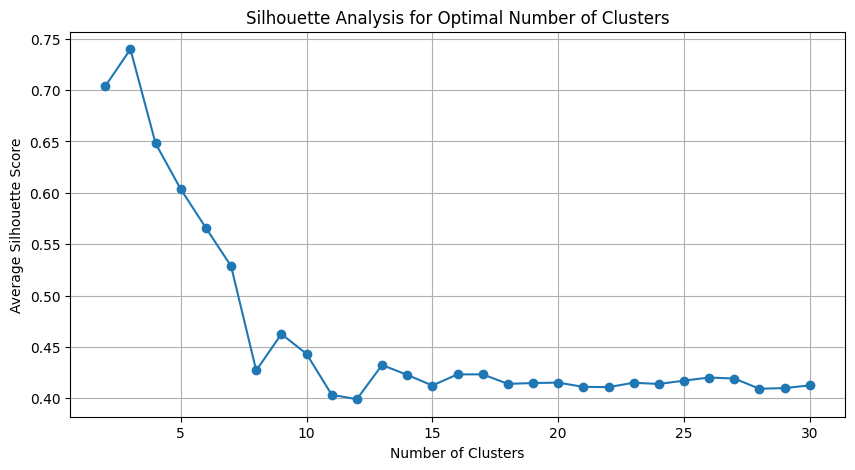

Optimal number of clusters based on Silhouette Analysis: 3


In [42]:
silhouette_scores = []
range_n_clusters = range(2, 31)  # Silhouette Score requires at least 2 clusters

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=33)
    cluster_labels = kmeans.fit_predict(x_pca)
    silhouette_avg = silhouette_score(x_pca, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {n_clusters}, the average silhouette score is: {silhouette_avg}")

# Plot Silhouette Scores
plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title('Silhouette Analysis for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Silhouette Score')
plt.grid(True)
plt.show()

# Determine the optimal number of clusters (maximum silhouette score)
optimal_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on Silhouette Analysis: {optimal_clusters}")

In [43]:
wcss = []
for i in range(1, 31):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=33)
    kmeans.fit(x_pca)
    wcss_iter = kmeans.inertia_
    wcss.append(wcss_iter)
    print(f"K = {i}, WCSS = {wcss_iter:.2f}")

K = 1, WCSS = 25385.11
K = 2, WCSS = 9467.47
K = 3, WCSS = 4246.07
K = 4, WCSS = 2949.20
K = 5, WCSS = 2460.58
K = 6, WCSS = 2032.58
K = 7, WCSS = 1760.73
K = 8, WCSS = 1582.06
K = 9, WCSS = 1309.89
K = 10, WCSS = 1233.88
K = 11, WCSS = 1100.50
K = 12, WCSS = 1015.37
K = 13, WCSS = 862.64
K = 14, WCSS = 819.40
K = 15, WCSS = 757.33
K = 16, WCSS = 698.08
K = 17, WCSS = 653.04
K = 18, WCSS = 626.57
K = 19, WCSS = 579.06
K = 20, WCSS = 546.23
K = 21, WCSS = 536.22
K = 22, WCSS = 502.82
K = 23, WCSS = 474.48
K = 24, WCSS = 450.03
K = 25, WCSS = 432.79
K = 26, WCSS = 412.37
K = 27, WCSS = 394.71
K = 28, WCSS = 392.86
K = 29, WCSS = 378.44
K = 30, WCSS = 352.46


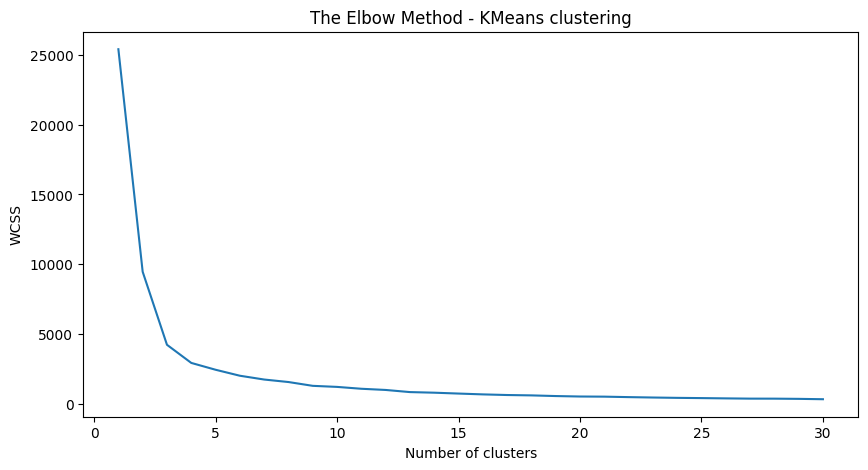

In [44]:
number_clusters = range(1, 31)
plt.figure(figsize=(10, 5))
plt.plot(number_clusters, wcss)
plt.title('The Elbow Method - KMeans clustering')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

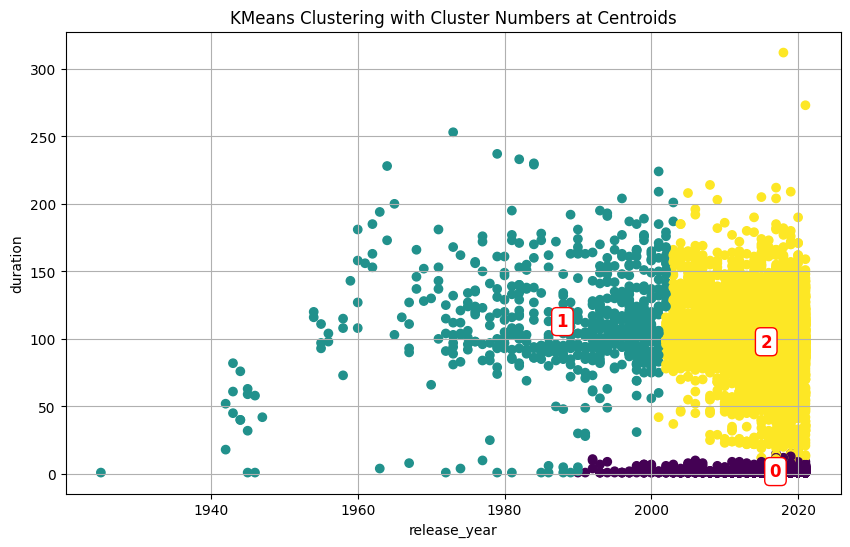

In [45]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Assume X is defined with two columns: release_year and duration
if isinstance(X, pd.DataFrame):
    X = X.values

# Step 1: Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: KMeans on scaled data
elbow_point = 3
kmeans = KMeans(n_clusters=elbow_point, init='k-means++', max_iter=300, n_init=10, random_state=33)
clusters = kmeans.fit_predict(X_scaled)

# Step 3: Inverse transform the centroids to match original scale
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

# Step 4: Plot using original data (for correct axis interpretation)
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', marker='o')

# Step 5: Add cluster numbers at centroids (in original scale)
for i, center in enumerate(centroids_original):
    plt.text(center[0], center[1], str(i), fontsize=12, fontweight='bold', color='red',
             ha='center', va='center', bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3'))

plt.title('KMeans Clustering with Cluster Numbers at Centroids')
plt.xlabel('release_year')
plt.ylabel('duration')
plt.grid(True)
plt.show()

In [46]:
# kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=33)
# cluster_labels = kmeans.fit_predict(x_pca)

# # Visualize the clusters
# plt.figure(figsize=(10, 5))
# plt.scatter(x_pca[:, 0], x_pca[:, 1], c=cluster_labels, cmap='viridis', marker='o')
# plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='x')
# plt.title(f'KMeans Clustering with {optimal_clusters} Clusters')
# plt.xlabel('PCA Component 1')
# plt.ylabel('PCA Component 2')
# plt.show()

In [47]:
# pivot_table = cluster_distribution.pivot_table(index='cluster', columns='type', values='count', fill_value=0)
# print(pivot_table)
# pivot_table.plot(kind='bar', stacked=True, figsize=(8, 6))
# plt.title('Distribution of Movies and TV Shows per Cluster')
# plt.xlabel('Cluster')
# plt.ylabel('Count')
# plt.legend(title='Type')
# plt.show()

In [48]:
# import seaborn as sns
# plt.figure(figsize=(8, 6))
# sns.boxplot(x='cluster', y='duration', data=net_df)
# plt.title('Distribution of Duration per Cluster')
# plt.show()

In [49]:
# Step 1: Add cluster labels to your original DataFrame
net_df_clustered = net_df.copy()
net_df_clustered['cluster'] = clusters

# Step 2: Group by cluster and type, then count
type_distribution = net_df_clustered.groupby(['cluster', 'type']).size().reset_index(name='count')

# Step 3: (Optional) Pivot for better readability
type_pivot = type_distribution.pivot(index='cluster', columns='type', values='count').fillna(0).astype(int)

# Step 4: Display the pivot table
print(type_pivot)


type     Movie  TV Show
cluster                
0            0     2646
1          569       18
2         5557        0


In [50]:
# Filter TV Shows that are in cluster 1
tv_shows_cluster_1 = net_df_clustered[(net_df_clustered['cluster'] == 1) & (net_df_clustered['type'] == 'TV Show') & (net_df_clustered['duration'] <= 30)]

# Display the result
print(tv_shows_cluster_1)


     show_id     type                                title  \
1331   s1332  TV Show  Five Came Back: The Reference Films   
2740   s2741  TV Show                          Saint Seiya   
4250   s4251  TV Show    Pioneers: First Women Filmmakers*   
4550   s4551  TV Show     Monty Python's Fliegender Zirkus   
4551   s4552  TV Show         Monty Python's Flying Circus   
5299   s5300  TV Show                            High Risk   
6549   s6550  TV Show                           Dad's Army   
6674   s6675  TV Show                             El Chavo   
6970   s6971  TV Show                    Highway to Heaven   
7588   s7589  TV Show                        Ninja Hattori   
7721   s7722  TV Show                  Pee-wee's Playhouse   
7743   s7744  TV Show  Pioneers of African-American Cinema   
7878   s7879  TV Show                             Robotech   
7993   s7994  TV Show                           Shaka Zulu   
8189   s8190  TV Show               The Andy Griffith Show   
8523   s

In [51]:
# Average duration for cluster 0
avg_duration_cluster_0 = net_df_clustered[net_df_clustered['cluster'] == 0]['duration'].mean()
avg_duration_cluster_1 = net_df_clustered[net_df_clustered['cluster'] == 1]['duration'].mean()
avg_duration_cluster_2 = net_df_clustered[net_df_clustered['cluster'] == 2]['duration'].mean()
max_duration_cluster_0 = net_df_clustered[net_df_clustered['cluster'] == 0]['duration'].max()
print(f"Average duration for cluster 0: {avg_duration_cluster_0:.2f} minutes")
print(f"Average duration for cluster 1: {avg_duration_cluster_1:.2f} minutes")
print(f"Average duration for cluster 2: {avg_duration_cluster_2:.2f} minutes")
print(f"Average duration for cluster 0: {max_duration_cluster_0:.2f} minutes")

Average duration for cluster 0: 1.74 minutes
Average duration for cluster 1: 112.80 minutes
Average duration for cluster 2: 97.88 minutes
Average duration for cluster 0: 17.00 minutes


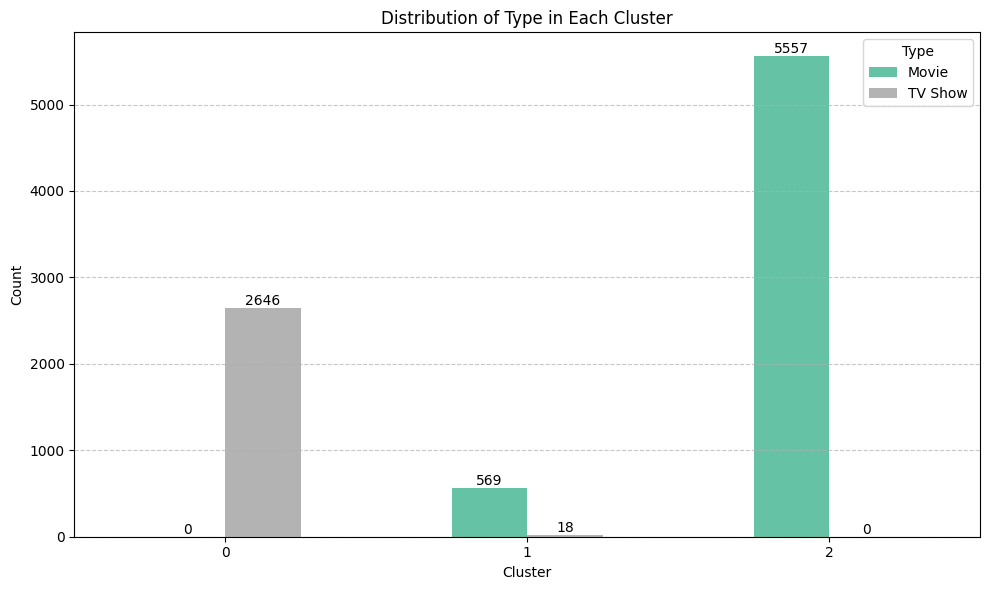

In [52]:
import matplotlib.pyplot as plt

# Step 1: Use the pivot table from before
ax = type_pivot.plot(kind='bar', figsize=(10, 6), colormap='Set2')

for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

# Step 2: Styling
plt.title('Distribution of Type in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [53]:
# range_n_clusters = range(2, 31)
# silhouette_avg = []
# for num_clusters in range_n_clusters:
#     kmeans = KMeans(n_clusters=num_clusters, init='k-means++', random_state=33)
#     kmeans.fit(x_pca)
#     cluster_labels = kmeans.labels_
#     silhouette_avg.append(silhouette_score(x_pca, cluster_labels))

In [54]:
# plt.figure(figsize=(10, 5))
# plt.plot(range_n_clusters, silhouette_avg)
# plt.xlabel('Values of K')
# plt.ylabel('Silhouette score')
# plt.title('Silhouette analysis for Optimal k - KMeans clustering')
# plt.show()

In [55]:
# kmeans = KMeans(n_clusters=3, init='k-means++', random_state=33)
# kmeans.fit(x_pca)

In [56]:
kmeans_distortion = kmeans.inertia_
kmeans_silhouette_score = silhouette_score(x_pca, kmeans.labels_)
print("Distortion (WCSS):", kmeans_distortion)
print("Silhouette Score:", kmeans_silhouette_score)

Distortion (WCSS): 5172.981926003985
Silhouette Score: 0.7396855260198941


In [57]:
# net_df['kmeans_cluster'] = kmeans.labels_

In [58]:
# import matplotlib.pyplot as plt
# import pandas as pd

# # Create a crosstab of cluster vs type
# cluster_type_dist = pd.crosstab(net_df['kmeans_cluster'],net_df['type'])

# # Plot as a grouped bar chart
# cluster_type_dist.plot(kind='bar', figsize=(10, 6), colormap='Set2')

# plt.title('Distribution of Type in Each Cluster')
# plt.xlabel('Cluster')
# plt.ylabel('Number of Items')
# plt.xticks(rotation=0)
# plt.legend(title='Type')
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()
